In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import squareform  
import tifffile
from skimage.measure import regionprops_table
import random
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree
from sklearn.metrics import adjusted_rand_score, silhouette_score, adjusted_mutual_info_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import adjusted_mutual_info_score

#### xy pixel size = 0.1893014, z pixel size = 0.7996567
XY_UM = 0.1893014
Z_UM = 0.7996567

directory = Path(r"z:\Jorge\SPACEFISH_analysis\2026\v121-vascu-rep1\results")
folders = []
for folder in directory.iterdir():
    if folder.is_dir():
        folders.append(folder)
folders_to_read = [f for f in folders if "noamp" not in f.name and "noim" not in f.name]
output_dir = Path(r"c:\Users\taylorhearn\git_repos\image_quantification\New_Spacefish")

# Read in the Data (Skip this, already loaded)
- You can now skip this and just read in the data directly from the csv 

In [52]:
def centroids_from_mask(mask: np.ndarray):
    """Return (props_df, (Xmax, Ymax, Zmax)). Mask assumed (Z, Y, X) if 3D."""
    mask = np.squeeze(mask)
    props = pd.DataFrame(regionprops_table(mask, properties=("label", "centroid")))
    props = props.rename(columns={
        "centroid-0": "nucleus_centroid_z",
        "centroid-1": "nucleus_centroid_y",
        "centroid-2": "nucleus_centroid_x",
    })
    zmax, ymax, xmax = mask.shape
    return props, (int(xmax), int(ymax), int(zmax))

In [ ]:
def check_one(folder: Path):
    """ Sanity check that we can use the NucleiLocation.csv data rather than reading in the segmentation mask each time
    Values of 0 mean the mask matches the csv data
    """
    seg_path = next(iter(folder.glob("*seg_mask.tif*")), None)
    xyz_path = next(iter(folder.glob("*NucleiLocation*.csv")), None)
    if seg_path is None or not xyz_path.exists():
        print("File Missing")
        return None

    mask = np.squeeze(tifffile.imread(str(seg_path)))
    props, (xmax, ymax, zmax) = centroids_from_mask(mask)
    props = props.rename(columns={"label": "nucleus"})

    xyz = pd.read_csv(xyz_path).rename(columns={"ID": "nucleus"})
    m = props.merge(xyz, on="nucleus", how="inner")

    # direct mapping (centroid_x vs xyz.x, etc.)
    dx = (m["nucleus_centroid_x"] - m["x"]).abs().round(3)
    dy = (m["nucleus_centroid_y"] - m["y"]).abs().round(3)
    dz = (m["nucleus_centroid_z"] - m["z"]).abs().round(3)
    return {
        "folder": folder.name,
        "mask_shape_ZYX": mask.shape,
        "n_matched": len(m),
        "max_dx": dx.max(), "max_dy": dy.max(), "max_dz": dz.max(),
        "mean_dx": dx.mean(), "mean_dy": dy.mean(), "mean_dz": dz.mean(),
    }

test = folders_to_read[1]
report = pd.DataFrame([check_one(test)])


In [ ]:
def source_root_name(folder: Path) -> str:
    """Name of the top-level root in folders_to_read that contains this folder."""
    rp = folder.resolve()
    for root in folders_to_read:
        rr = root.resolve()
        if rp == rr or rr in rp.parents:
            return root.name
    return "UNKNOWN"

def mask_extent(seg_path: Path):
    """Read only the array shape (no pixel data) -> (Xmax, Ymax, Zmax)."""
    shape = tifffile.TiffFile(str(seg_path)).series[0].shape
    zmax, ymax, xmax = tuple(s for s in shape if s > 1)  # drop singleton axes
    return int(xmax), int(ymax), int(zmax)

all_tables = []

for folder in folders_to_read:
    print(folder)
    count_csv = next(iter(folder.glob("*count_table*.csv")), None)
    seg_path = next(iter(folder.glob("*seg_mask.tif")), None)
    xyz_path = next(iter(folder.glob("*NucleiLocation*.csv")), None)

    if seg_path is None:
        print(f"[SKIP - no seg_mask] {folder}")
        continue
    if not xyz_path.exists():
        print(f"[SKIP - no nucleus_xyz.csv] {folder}")
        continue
    if not count_csv.exists():
        print(f"[SKIP - no count_table.csv] {folder}")
        continue

    df = pd.read_csv(count_csv)

    # Centroids from nucleus_xyz.csv (fast). NOTE: validated x<->y swap vs seg_mask.
    xyz = pd.read_csv(xyz_path).rename(columns={
        "ID": "nucleus",
        "x": "nucleus_centroid_y",   # csv 'x' is image row (Y)
        "y": "nucleus_centroid_x",   # csv 'y' is image column (X)
        "z": "nucleus_centroid_z",
    })[["nucleus", "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z"]]
    df = df.merge(xyz, on="nucleus", how="left")

    # Extent from mask header only (no full load).
    xmax, ymax, zmax = mask_extent(seg_path)
    df["Xmax"], df["Ymax"], df["Zmax"] = xmax, ymax, zmax

    # Provenance: which root folder this image came from.
    df.insert(0, "source_folder", source_root_name(folder))

    out_name = f"{folder.name}_count_table_xyz.csv"
    df.to_csv(output_dir / out_name, index=False)
    all_tables.append(df)
    print(f"[OK] {folder.name} [{df['source_folder'].iloc[0]}]: "
          f"{len(df)} nuclei, extent (X,Y,Z)=({xmax},{ymax},{zmax})")

# Concatenate every nucleus from every image into one table.
if all_tables:
    combined = pd.concat(all_tables, ignore_index=True)
    combined.to_csv(output_dir / "all_nuclei.csv", index=False)
    print(f"\nCombined table: {combined.shape[0]} nuclei x {combined.shape[1]} columns")
    print(f"Saved -> {output_dir / 'all_nuclei.csv'}")
else:
    print("\nNo folders produced output.")


# Read Gene Counts (Run from Here)
- iterate through folders and extract counts
- define cells as endothelilal/fibroblast/unknown

In [2]:
combined = pd.read_csv(output_dir / "all_nuclei.csv")

In [3]:
endo_genes = ["CDH5", "PECAM1", "VWF", "KDR", "FLT1", "PDGFB"]
fibro_genes = ["PDGFRB", "COL1A1", "COL1A2"]

# Lineage from marker PRESENCE: ne / nf = how many endo / fibro markers a cell detects.
# Confidence is purity-based - a "confident" cell expresses one lineage's markers and
# NONE of the other's. Because the confident sets contain zero markers of the opposite
# lineage, a cross-lineage pair (e.g. COL1A1 inside endothelial) can never appear there,
# which is what removes the circular artefact without needing leave-two-out downstream.
endo_on = (combined[endo_genes].fillna(0) > 0).sum(axis=1)
fibro_on = (combined[fibro_genes].fillna(0) > 0).sum(axis=1)
combined["n_endo_markers"] = endo_on
combined["n_fibro_markers"] = fibro_on
combined["endothelial_score"] = endo_on / len(endo_genes)
combined["fibroblast_score"] = fibro_on / len(fibro_genes)

def lineage_tier(ne, nf):
    """Order cells along the endothelial<->fibroblast axis into 5 confidence tiers.
    Confident = at least 2 of its own markers and none of the other lineage's."""
    if ne >= 2 and nf == 0:
        return "endothelial (confident)"
    if nf >= 2 and ne == 0:
        return "fibroblast (confident)"
    if ne > nf:
        return "endothelial (tentative)"
    if nf > ne:
        return "fibroblast (tentative)"
    return "unknown"                     # tie, incl. no markers at all

combined["lineage_tier"] = [lineage_tier(ne, nf) for ne, nf in zip(endo_on, fibro_on)]
combined["cell_type"] = combined["lineage_tier"].str.split().str[0]   # endothelial/fibroblast/unknown
combined["confident"] = combined["lineage_tier"].str.contains("confident")

TIER_ORDER = ["endothelial (confident)", "endothelial (tentative)", "unknown",
              "fibroblast (tentative)", "fibroblast (confident)"]
print(combined["lineage_tier"].value_counts().reindex(TIER_ORDER))


lineage_tier
endothelial (confident)    4163
endothelial (tentative)    3225
unknown                    4927
fibroblast (tentative)      441
fibroblast (confident)      291
Name: count, dtype: int64


In [4]:
# Tidy matrix: genes are either on (1+ counts) or off (0 counts). Drop FP readouts and create a readable gene state for on genes (e.g. 1_4_12)
metadata_cols = {
    "name", "source_folder", "nucleus",
    "nucleus_centroid_x", "nucleus_centroid_y", "nucleus_centroid_z", 
    "Xmax", "Ymax", "Zmax", "cell_type", "endothelial_score", "fibroblast_score",
    "n_endo_markers", "n_fibro_markers", "lineage_tier", "confident", "had_reads",
    "marker_cluster", "cell_type_clustering",  # unsupervised cell-typing outputs
    "state_code", "binary_state",  # derived label columns, not genes
}
gene_columns = [c for c in combined.columns if c not in metadata_cols]
fp_columns = [c for c in gene_columns if c.startswith("FP")]
true_gene_columns = [c for c in gene_columns if not c.startswith("FP")]

combined[true_gene_columns] = (combined[true_gene_columns].fillna(0).astype(float) > 0).astype(int)
combined["state_code"] = combined[true_gene_columns].apply(
    lambda row: "_".join(str(i + 1) for i, value in enumerate(row) if value == 1), axis=1,
).replace("", "0")  # all-negative cells get the code "0"
true_gene_dictionary = {c: i for i, c in enumerate(true_gene_columns)}

# # binary_state: one digit per gene in column order, e.g. "100100000001000000"
combined["binary_state"] = combined[true_gene_columns].astype(str).agg("".join, axis=1)


In [5]:
# Keep ALL cells and ALL states (no rare-state filtering). The all-0-read cells carry no
# transcripts, so for the full-population pairwise we split them into endothelial /
# fibroblast at the ratio of the CONFIDENT cells (seeded, reproducible). They stay
# flagged by had_reads=False and confident=False, so they never enter the lineage-
# specific (confident-only) analysis.
combined["had_reads"] = combined[true_gene_columns].sum(axis=1) > 0

conf_endo = int((combined["lineage_tier"] == "endothelial (confident)").sum())
conf_fibro = int((combined["lineage_tier"] == "fibroblast (confident)").sum())
p_fibro = conf_fibro / (conf_endo + conf_fibro)

zero_idx = combined.index[~combined["had_reads"]].to_numpy().copy()
rng = np.random.default_rng(0)
rng.shuffle(zero_idx)
n_fibro = int(round(p_fibro * len(zero_idx)))
combined.loc[zero_idx[:n_fibro], "cell_type"] = "fibroblast"
combined.loc[zero_idx[n_fibro:], "cell_type"] = "endothelial"
print(f"Confident ratio endo:fibro = {conf_endo}:{conf_fibro} "
      f"-> {len(zero_idx):,} all-0 cells split as "
      f"{len(zero_idx) - n_fibro:,} endothelial / {n_fibro:,} fibroblast")


Confident ratio endo:fibro = 4163:291 -> 3,575 all-0 cells split as 3,341 endothelial / 234 fibroblast


In [6]:
n_total = len(combined)
state_counts = combined.loc[combined["had_reads"], "state_code"].value_counts()
print(f"All cells:                     {n_total:,}")
print(f"Cells with >=1 transcript:     {combined['had_reads'].sum():,} "
      f"({100 * combined['had_reads'].mean():.1f}%)")
print(f"Unique expressed states:       {state_counts.size:,} (all kept, rare states retained)")
print(f"Singleton states (1 cell):     {(state_counts == 1).sum():,}")

print("\nConfident cells per lineage (used for the lineage-specific pairwise):")
print(combined.loc[combined["confident"], "cell_type"].value_counts())


All cells:                     13,047
Cells with >=1 transcript:     9,472 (72.6%)
Unique expressed states:       1,555 (all kept, rare states retained)
Singleton states (1 cell):     908

Confident cells per lineage (used for the lineage-specific pairwise):
cell_type
endothelial    4163
fibroblast      291
Name: count, dtype: int64


# Spatial & genetic subpopulation analysis

From here the lineage is the **scoring** definition (`cell_type` + `confident`). The
working frame **`df`** keeps **every cell and every state** (no rare-state filtering);
the all-0-read cells have been split into lineages at the confident ratio so they can
join the full-population statistics.

**Coordinates** are converted to microns using the acquisition pixel sizes
(xy = 0.1893014 um, z = 0.7996567 um), and every spatial calculation is performed
*within each image* (`source_folder`) so neighbourhoods never span different images.

**Roadmap**
1. **Pairwise gene interactions** - the full population (all cells, incl. all-0 and
   unknown), then endothelial and fibroblast separately using **confident cells only**.
2. **Gene states -> cell states** - a probabilistic Bernoulli mixture and KMeans, fused
   into a consensus (Section 2, left for later).
3. **Neighbourhood analysis** - per-cell micro-environment, then niches.
4. **Graph-based approaches** - spatial cell graph and gene-state graph.

## 0. Setup - analysis frame & physical coordinates



In [7]:
# Working frame: EVERY cell, scoring lineage definition (cell_type / confident / tier).
df = combined.copy().reset_index(drop=True)

In [8]:
# Convert to physical coordinates witin the image (each image has its own coordinate origin)
GENES = list(true_gene_columns)      # the 18 real genes (FP channels excluded)
IMAGE_KEY = "source_folder"          # one physical image per source_folder

# Working frame + physical coordinates.
df["x_um"] = df["nucleus_centroid_x"] * XY_UM
df["y_um"] = df["nucleus_centroid_y"] * XY_UM
df["z_um"] = df["nucleus_centroid_z"] * Z_UM

# Binary gene matrix (cells x genes) reused throughout.
X = df[GENES].astype(int).to_numpy()

# Consistent colours for the three cell types.
CT_ORDER = ["endothelial", "fibroblast", "unknown"]
CT_COLORS = {"endothelial": "#d62728", "fibroblast": "#1f77b4", "unknown": "#7f7f7f"}

print("\nCell-type counts:")
print(df["cell_type"].value_counts())


Cell-type counts:
cell_type
endothelial    10729
unknown         1352
fibroblast       966
Name: count, dtype: int64


## 1. Pairwise gene interactions

Which genes switch on together, and which are mutually exclusive? For every pair we
build a 2x2 on/off table, compute the odds ratio, and test it with **Fisher's exact
test** (Benjamini-Hochberg FDR).

- **Global (full population).** All 18 genes across **every** cell, including the all-0
  cells (split into lineages by the confident ratio) and the unknown-lineage cells.
  This asks which genes co-occur in the population as a whole. Note that the many
  both-off cells inflate positive odds ratios (the empty bottom-right corner of the
  2x2), so the global map is best read for *relative* structure, not absolute effect
  sizes.
- **Within lineage (confident cells only).** Splitting on `cell_type` and then testing
  two *marker* genes is circular - the markers helped define the lineage. Instead of
  leave-two-out, we restrict each lineage to its **confident** cells (>=2 of that
  lineage's markers and **none** of the other lineage's). Cross-lineage pairs (e.g.
  `COL1A1` inside endothelial) are then all-zero -> not testable, so the cross-lineage
  artefact cannot arise.
  - **Caveat (collider bias).** Selecting on ">=2 of a lineage's markers" makes *those
    markers* artificially anti-correlate within the subset (Berkson's paradox). So a
    pair where **both** genes are that lineage's defining markers is not interpretable -
    most visible for fibroblast, where "2 of 3" forces `COL1A1`/`COL1A2`/`PDGFRB` to
    look mutually exclusive. We therefore **flag and exclude defining-marker pairs** and
    read only the non-marker pairs (e.g. `APLN`-`ANGPT2`, `MMP1`-`DLL4` in endothelial),
    which carry no such bias.



In [45]:
# Pairwise gene co-occurrence via Fisher's exact test.
# log2 OR > 0 -> genes cooccur more than expected
# log2 OR < 0 -> genes are mutually exclusive

# added cutoffs for more biologically meaningful results:
# mask any pair where a gene is on in <min_pos cells and only trust a negative when n1n2/N > 1 (i.e. we don't just see no cooccurrent because both genes are rare)
def pairwise_cooccurrence(binary_df, genes, title="", ax=None,
                          min_pos=5, min_expected=1.0):
    """Pairwise gene co-occurrence via Fisher's exact test.

    min_pos       : a gene must be ON in >= this many cells for the pair to be shown
                    (otherwise the odds ratio is unstable).
    min_expected  : a NEGATIVE (mutually exclusive) call is only kept when the
                    expected overlap n1*n2/N >= this; below it there is no power
                    to detect depletion, so it is masked.
    """
    N = len(binary_df)
    present = {g: int((binary_df[g] == 1).sum()) for g in genes}
    rows = []
    for i, g1 in enumerate(genes):
        for g2 in genes[i + 1:]:
            a = int(((binary_df[g1] == 1) & (binary_df[g2] == 1)).sum())
            b = int(((binary_df[g1] == 1) & (binary_df[g2] == 0)).sum())
            c = int(((binary_df[g1] == 0) & (binary_df[g2] == 1)).sum())
            d = int(((binary_df[g1] == 0) & (binary_df[g2] == 0)).sum())
            odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
            _, p = fisher_exact([[a, b], [c, d]])
            expected = present[g1] * present[g2] / N   # overlap expected if independent
            rows.append(dict(gene1=g1, gene2=g2, both=a, odds_ratio=odds, pvalue=p,
                             n1=present[g1], n2=present[g2], expected=expected))
    res = pd.DataFrame(rows)
    res["FDR"] = multipletests(res.pvalue, method="fdr_bh")[1]
    res["log2_OR"] = np.log2(res.odds_ratio)

    # A pair is "testable" only if both genes clear the marginal cutoff.
    res["testable"] = (res.n1 >= min_pos) & (res.n2 >= min_pos)
    # Exclusivity (negative OR) additionally needs a detectable expected overlap.
    res["exclusivity_reliable"] = res.testable & (res.expected >= min_expected)

    M = pd.DataFrame(np.nan, index=genes, columns=genes)
    for _, r in res.iterrows():
        if not r.testable:
            continue                      # too few positives -> leave blank
        if r.log2_OR < 0 and not r.exclusivity_reliable:
            continue                      # can't trust a "mutually exclusive" call
        M.loc[r.gene1, r.gene2] = r.log2_OR
        M.loc[r.gene2, r.gene1] = r.log2_OR


    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))   # only make a figure if none passed
    lim = np.nanmax(np.abs(M.values)) if np.isfinite(M.values).any() else 1.0
    sns.heatmap(M, cmap="coolwarm", center=0, vmin=-lim, vmax=lim, square=True,
                mask=M.isna(), ax=ax, cbar_kws={"label": "log2 odds ratio"})
    ax.set_title(title)
    return res, M

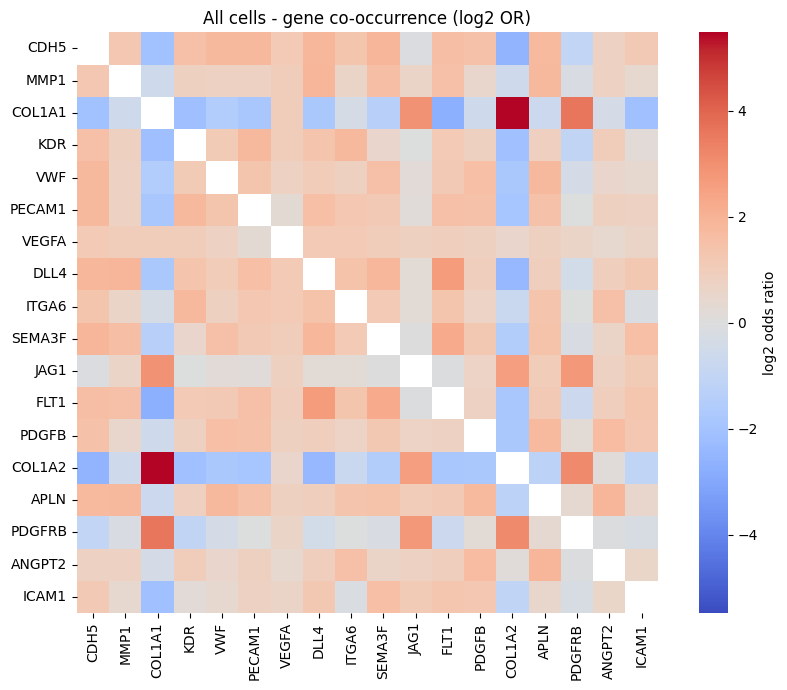

Significant pairs (FDR<0.05): 123  (co-occurring: 101, exclusive: 22)

Most significant co-occurring gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,608,509,278,23.719782,44.439079,5.473757,2.855165e-252
2,CDH5,KDR,4889,3548,1981,1329.514218,2.864849,1.518459,2.547955e-149
3,CDH5,VWF,4889,2269,1403,850.244577,3.387900,1.760391,1.122826e-146
4,CDH5,PECAM1,4889,1960,1225,734.455430,3.375395,1.755056,5.946295e-130
49,KDR,PECAM1,3548,1960,994,533.002223,3.437354,1.781298,1.206684e-127
6,CDH5,DLL4,4889,1393,913,521.987967,3.671052,1.876194,2.521302e-110
101,DLL4,FLT1,1393,721,278,76.979612,6.311400,2.657960,1.171710e-91
5,CDH5,VEGFA,4889,3845,1950,1440.806699,2.192632,1.132664,6.604292e-88
8,CDH5,SEMA3F,4889,922,619,345.493830,3.754721,1.908706,1.601486e-78
22,MMP1,DLL4,1178,1393,317,125.772515,3.695189,1.885648,1.482674e-60


Most significant mutually-exclusive gene pairs:


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
12,CDH5,COL1A2,4889,509,48,190.733579,0.167086,-2.581338,1.342468e-47
1,CDH5,COL1A1,4889,608,78,227.831072,0.234608,-2.091676,1.026105e-42
33,COL1A1,KDR,608,3548,48,165.339465,0.220978,-2.178025,1.859079e-33
57,KDR,COL1A2,3548,509,41,138.417414,0.228087,-2.132343,1.460748e-27
35,COL1A1,PECAM1,608,1960,30,91.337472,0.287018,-1.800788,4.920342e-15
70,VWF,COL1A2,2269,509,30,88.520043,0.292534,-1.773324,2.565429e-14
34,COL1A1,VWF,608,2269,42,105.737104,0.343956,-1.539702,5.261975e-14
82,PECAM1,COL1A2,1960,509,23,76.465088,0.264308,-1.919707,5.414428e-14
103,DLL4,COL1A2,1393,509,11,54.344830,0.186164,-2.425355,3.267477e-13
37,COL1A1,DLL4,608,1393,21,64.914846,0.295099,-1.760729,8.418605e-11


In [49]:
#  Full population (all cells, incl. all-0 and unknown lineage)
res_all, M_all = pairwise_cooccurrence(
    df, GENES, title="All cells - gene co-occurrence (log2 OR)")
plt.tight_layout(); plt.show()

# Readable labels for the summary tables.
show_cols = {
    "gene1": "gene1", "gene2": "gene2",
    "n1": "# cells gene1 on", "n2": "# cells gene2 on",
    "both": "# overlap (both on)", "expected": "# overlap expected",
    "odds_ratio": "odds_ratio", "log2_OR": "log2_OR", "FDR": "FDR",
}
cols = list(show_cols)

sig = res_all[res_all.FDR < 0.05].copy()
sig.to_csv("all_cells_sig_pairs.csv")
print(f"Significant pairs (FDR<0.05): {len(sig)}  "
      f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
print("\nMost significant co-occurring gene pairs:")
display(sig[sig.log2_OR > 0].sort_values("FDR").head(20)[cols].rename(columns=show_cols))
print("Most significant mutually-exclusive gene pairs:")
display(sig[sig.log2_OR < 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))

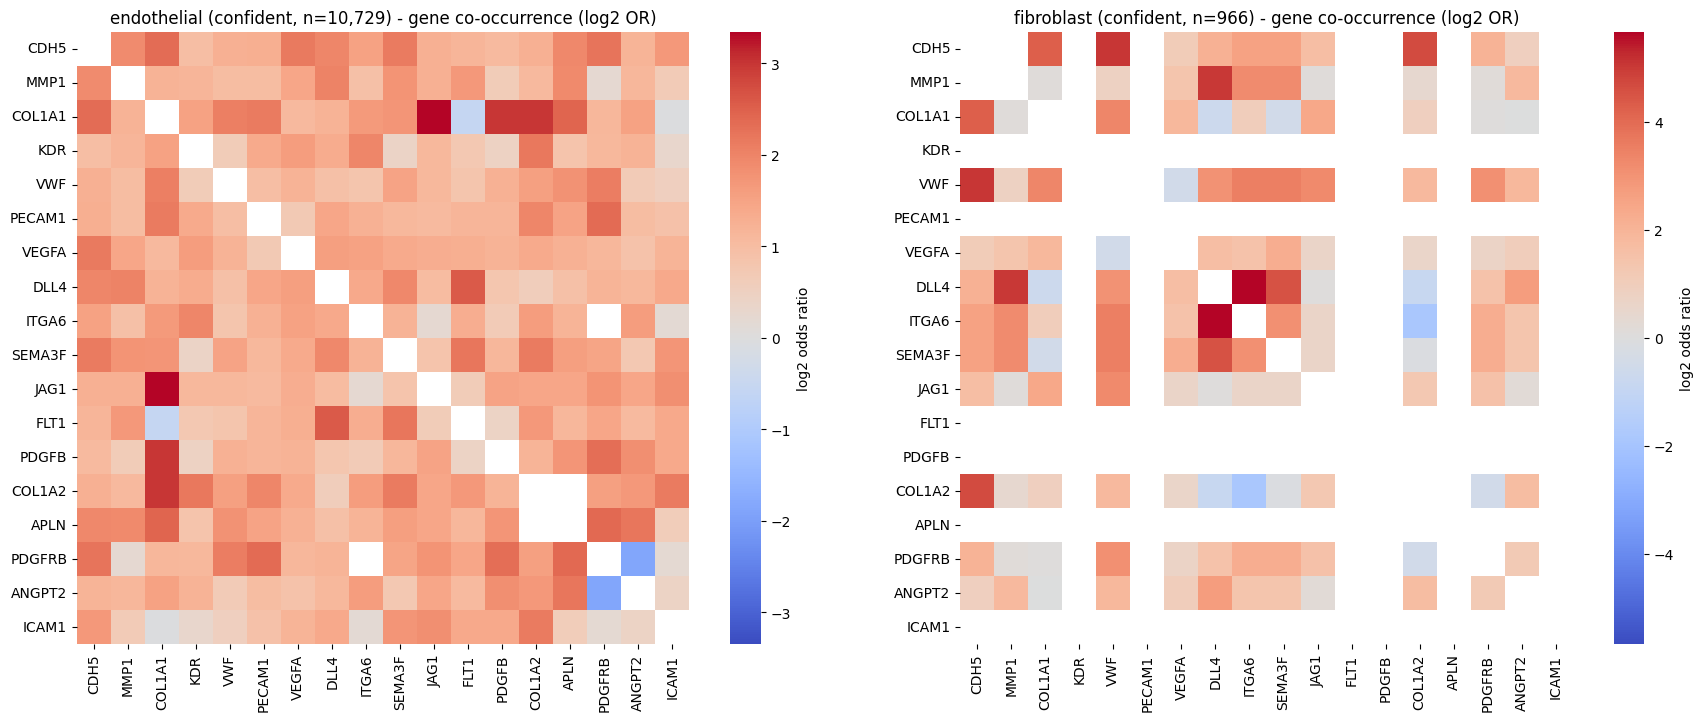

In [69]:
# Within-lineage co-occurrence WITHOUT circularity - use CONFIDENT cells only.
# A confident cell expresses >=2 of its lineage's markers and NONE of the other's, so
# the opposite lineage's markers are all-zero here and their pairs are simply not
# testable. No leave-two-out needed: any testable pair is a genuine co-occurrence.
lineages = ["endothelial", "fibroblast"]
fig, axes = plt.subplots(1, len(lineages), figsize=(9 * len(lineages), 7))
lineage_res = {}
for ax, lineage in zip(axes, lineages):
    sub = df[(df["cell_type"] == lineage)] # & (df["confident"])]
    res, M = pairwise_cooccurrence(
        sub, GENES, ax=ax, 
        title=f"{lineage} (confident, n={len(sub):,}) - gene co-occurrence (log2 OR)")
    lineage_res[lineage] = res
plt.tight_layout(); plt.show()

In [50]:
# Significant within-lineage pairs (confident cells only).
# CAVEAT: a "confident" cell is selected on >=2 of its own markers, which makes those
# defining markers artificially anti-correlate within the subset (collider / Berkson
# bias). So pairs where BOTH genes are that lineage's markers are NOT interpretable -
# we flag them and report the trustworthy (non-marker) pairs separately.
lineage_markers = {"endothelial": set(endo_genes), "fibroblast": set(fibro_genes)}

for lineage in ["endothelial", "fibroblast"]:
    res = lineage_res[lineage].copy()
    mk = lineage_markers[lineage]
    res["both_defining"] = res.gene1.isin(mk) & res.gene2.isin(mk)
    testable = res[res.testable]
    trust = testable[~testable.both_defining]          # interpretable pairs
    biased = testable[testable.both_defining]          # collider-biased, do not interpret
    sig = trust[trust.FDR < 0.05]
    print(f"{lineage}: {len(testable)} testable pairs "
          f"({len(trust)} interpretable, {len(biased)} defining-marker pairs excluded); "
          f"{len(sig)} interpretable & significant (FDR<0.05)  "
          f"(co-occurring: {(sig.log2_OR > 0).sum()}, exclusive: {(sig.log2_OR < 0).sum()})")
    print("  most significant co-occurring (non-marker pairs):")
    display(sig[sig.log2_OR > 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))
    print("  most significant mutually-exclusive (non-marker pairs):")
    display(sig[sig.log2_OR < 0].sort_values("FDR").head(10)[cols].rename(columns=show_cols))
    if len(biased):
        print("  defining-marker pairs (collider-biased, NOT interpreted):")
        display(biased[cols].rename(columns=show_cols))

endothelial: 105 testable pairs (90 interpretable, 15 defining-marker pairs excluded); 28 interpretable & significant (FDR<0.05)  (co-occurring: 25, exclusive: 3)
  most significant co-occurring (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
101,DLL4,FLT1,885,612,243,130.103291,2.984213,1.577350,7.203636e-28
118,SEMA3F,FLT1,550,612,154,80.855153,2.681724,1.423161,7.048073e-17
22,MMP1,DLL4,599,885,206,127.339659,2.228471,1.156054,1.264766e-14
99,DLL4,SEMA3F,885,550,175,116.922892,1.909963,0.933545,6.726080e-09
141,PDGFB,ANGPT2,690,262,81,43.425414,2.425677,1.278388,2.839330e-08
26,MMP1,FLT1,599,612,132,88.058612,1.819389,0.863454,1.809007e-06
5,CDH5,VEGFA,3306,1704,1418,1353.212587,1.498318,0.583344,3.503819e-06
24,MMP1,SEMA3F,599,550,118,79.137641,1.782490,0.833894,1.059802e-05
148,APLN,ANGPT2,160,262,26,10.069661,3.138670,1.650154,4.018940e-05
124,SEMA3F,ICAM1,550,182,45,24.045160,2.275777,1.186359,1.154112e-04


  most significant mutually-exclusive (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
75,PECAM1,VEGFA,1655,1704,564,677.424934,0.620568,-0.688338,4.236346e-12
53,KDR,SEMA3F,2565,550,266,338.878213,0.535479,-0.901099,1.877358e-10
61,KDR,ICAM1,2565,182,92,112.137881,0.623342,-0.681904,9.983903e-03


  defining-marker pairs (collider-biased, NOT interpreted):


...

,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR


  most significant mutually-exclusive (non-marker pairs):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR


  defining-marker pairs (collider-biased, NOT interpreted):


,gene1,gene2,# cells gene1 on,# cells gene2 on,# overlap (both on),# overlap expected,odds_ratio,log2_OR,FDR
43,COL1A1,COL1A2,280,260,249,250.171821,0.344375,-1.537946,1.000000e+00
45,COL1A1,PDGFRB,280,78,67,75.051546,0.013746,-6.184839,2.269806e-05
144,COL1A2,PDGFRB,260,78,47,69.690722,0.003531,-8.145517,1.461939e-18


## 2. Which gene states define distinct cell states?

**Biological question:** we've converted the on/off genes into a single 18-gene state. Can we group those into families of cell state, and are those groups robust to the clustering method used? We cluster within each cell type, otherwise the dominant split is simply endothelial vs fibroblast.

We use two complementary methods, plus a consensus of the two:

| Approach | Type | What a cluster **is** |
|---|---|---|
| KMeans (at matched K) | distance-based | a **centroid** = the per-gene ON-fraction; cells join the nearest centroid in Euclidean distance |
| Bernoulli mixture | probabilistic | a hidden **state** with a per-gene ON-probability; each cell is a noisy draw from one state, K chosen by BIC |
| Consensus | ensemble | fuses the two by co-association - cells stay together only when **both** methods agree - and scores a **per-cell confidence** |

**Why these two (and why they mostly agree).** A KMeans centroid and a Bernoulli state describe a cluster by almost the same object - a per-gene ON-probability - so on well-separated, balanced structure they give nearly identical partitions. Hierarchical clustering was dropped: on sparse 0/1 data hundreds of states sit at identical Jaccard/Hamming distances, so its "merge the nearest pair" rule breaks ties by input order rather than biology, making it unstable and the persistent outlier.

**Where they differ - and why we keep both.**
- **Assignment.** KMeans is **hard** (one label per cell); the Bernoulli mixture is **soft** (a probability per state), so it handles cells that sit between programmes.
- **Per-gene weighting.** KMeans (Euclidean) weights every gene equally, so a common, flaky gene can drive a split. The Bernoulli model weights each gene by how consistently it is on within a state, so clean markers dominate and noisy common genes matter less. This is exactly where the two disagree - and where the Bernoulli answer is usually the more biological one.
- **Choosing K.** Only the Bernoulli mixture selects K (by BIC); that same K is **forced on KMeans**, so a low agreement means genuine disagreement, not a granularity mismatch.

Because they belong to different families (distance-based vs generative), their **agreement is itself evidence**: high agreement between them means the structure is real biology rather than an artefact of one clustering choice. We score that agreement with the **Adjusted Mutual Information** (AMI), a single chance-corrected number that (unlike the Rand index) stays reliable when the groups are very uneven in size - which ours are. Running both methods is also what makes the **consensus + per-cell confidence** meaningful: it needs at least two partitions to fuse.



In [9]:
# Shared helpers + a readable cluster summariser used by every approach in section 2.

def binary_state_to_code(binary_state):
    """'100100...' -> '1_4' (1-indexed positions of the ON genes; '0' if none on)."""
    genes_on = [str(position + 1) for position, bit in enumerate(binary_state) if bit == "1"]
    return "_".join(genes_on) if genes_on else "0"


def state_code_to_gene_names(state_code, genes):
    """'1_4_7' -> 'CDH5, KDR, VWF' using the 1-indexed gene order ('0' -> 'none')."""
    if state_code == "0":
        return "none"
    return ", ".join(genes[int(position) - 1] for position in state_code.split("_"))


def describe_clusters(cells, cell_labels, genes, method_name, cell_type, top_states=3):
    """Print a plain-English summary of one method's clusters for one cell type.

    For every cluster it lists the gene states that dominate it, e.g.
    "cluster 1 (120 cells, 34%): likely states include 60% 1_4 (CDH5, KDR); ...".
    Cells with label -1 (unassigned) are ignored. Returns the same information as a
    tidy DataFrame so it can be collected and saved.
    """
    labels = pd.Series(cell_labels, index=cells.index)
    assigned = labels[labels >= 0]
    cluster_sizes = assigned.value_counts()
    n_cells = len(assigned)
    print(f"{len(cluster_sizes)} clusters identified for {cell_type} cells "
          f"({method_name}, {n_cells:,} cells):")

    summary_rows = []
    for cluster_id in cluster_sizes.index:
        member_index = assigned[assigned == cluster_id].index
        n = len(member_index)
        state_counts = cells.loc[member_index, "binary_state"].value_counts()
        described = [
            f"{100 * count / n:.0f}% {binary_state_to_code(state)} "
            f"({state_code_to_gene_names(binary_state_to_code(state), genes)})"
            for state, count in state_counts.head(top_states).items()
        ]
        main_states = "; ".join(described)
        print(f"  cluster {cluster_id} ({n:,} cells, {100 * n / n_cells:.0f}%): "
              f"likely states include {main_states}")
        summary_rows.append({
            "cell_type": cell_type,
            "method": method_name,
            "cluster": cluster_id,
            "n_cells": n,
            "pct_of_cell_type": 100 * n / n_cells,
            "main_states": main_states,
        })
    print()
    return pd.DataFrame(summary_rows)


# ---- Consensus clustering: fuse the two methods into one robust partition ----

def consensus_labels(method_label_dict, n_clusters, max_cells=8000):
    """Fuse per-cell labels from several methods via a co-association matrix.

    For every pair of cells we count in how many of the input methods they land in the
    same cluster; dividing by the number of methods gives a co-association in [0, 1]
    (1.0 = every method groups them together). Average-linkage clustering of
    (1 - co-association) keeps two cells together only when the methods agree, so the
    result is robust to any single algorithm's quirks.

    Also returns a PER-CELL confidence: the mean co-association between a cell and the
    other members of its own consensus cluster. High confidence = the methods
    consistently co-group that cell; low confidence flags cells sitting in the ambiguous
    continuum between states. This lets us quantify how much of a lineage is genuinely
    structured versus method-dependent.

    Returns (labels, confidence), or (None, None) if there are too many cells to build
    the dense n x n matrix.
    """
    label_arrays = [np.asarray(lab) for lab in method_label_dict.values()]
    n = len(label_arrays[0])
    if n > max_cells:
        return None, None
    co_association = np.zeros((n, n), dtype=np.float64)
    for lab in label_arrays:
        co_association += (lab[:, None] == lab[None, :])
    co_association /= len(label_arrays)

    tree = linkage(squareform(1.0 - co_association, checks=False), method="average")
    labels = fcluster(tree, t=n_clusters, criterion="maxclust")

    confidence = np.full(n, np.nan)
    for cluster_id in np.unique(labels):
        members = np.where(labels == cluster_id)[0]
        if len(members) > 1:
            block = co_association[np.ix_(members, members)]
            # exclude the cell's self-association (always 1.0) from its own mean
            confidence[members] = (block.sum(axis=1) - 1.0) / (len(members) - 1)

    return labels, confidence


In [10]:
#  Approach 2: Bernoulli mixture (probabilistic) 

def fit_bernoulli_mixture_once(gene_matrix, n_states, max_iter=300, tol=1e-6, rng=None):
    """One EM run of a Bernoulli mixture.

    Returns (weights, on_probabilities, log_likelihood, responsibilities).
    """
    rng = rng if rng is not None else np.random.default_rng(0)
    n_cells, n_genes = gene_matrix.shape
    on_probabilities = rng.uniform(0.1, 0.9, size=(n_states, n_genes))
    weights = np.full(n_states, 1.0 / n_states)
    log_likelihood_prev = -np.inf
    responsibilities = np.full((n_cells, n_states), 1.0 / n_states)
    for _ in range(max_iter):
        log_prob = (gene_matrix @ np.log(on_probabilities.T)
                    + (1 - gene_matrix) @ np.log(1 - on_probabilities.T)) + np.log(weights)
        row_max = log_prob.max(axis=1, keepdims=True)
        log_norm = row_max.ravel() + np.log(np.exp(log_prob - row_max).sum(axis=1))
        log_likelihood = log_norm.sum()
        responsibilities = np.exp(log_prob - log_norm[:, None])
        cells_per_state = responsibilities.sum(axis=0) + 1e-9
        weights = cells_per_state / n_cells
        on_probabilities = np.clip((responsibilities.T @ gene_matrix) / cells_per_state[:, None],
                                   1e-3, 1 - 1e-3)
        if abs(log_likelihood - log_likelihood_prev) < tol * (abs(log_likelihood_prev) + 1e-9):
            break
        log_likelihood_prev = log_likelihood
    return weights, on_probabilities, log_likelihood, responsibilities

def fit_bernoulli_mixture(gene_matrix, n_states, n_restarts=8, seed=0):
    """Sort cells into `n_states` hidden states using a Bernoulli mixture.

    The idea: imagine a few hidden cell states. Each state has, for every gene, a
    chance that the gene is switched on, and each cell is a slightly noisy copy of one
    state. Fitting the model tells us those states and which one each cell most likely
    belongs to. Because it is a probability model of how the on/off patterns arise, it
    is a good sanity check on the distance-based clustering. It assumes genes turn on
    independently within a state and that a 0 really means "off" (not just missed).

    Runs the fit several times from random starts and keeps the best. Returns a dict
    with the state weights, per-gene on-probabilities, one hard label per cell, and the
    BIC score (lower = better fit once the number of states is penalised).
    """
    gene_matrix = np.asarray(gene_matrix, dtype=float)
    rng = np.random.default_rng(seed)
    best_fit = None
    for _ in range(n_restarts):
        candidate = fit_bernoulli_mixture_once(gene_matrix, n_states, rng=rng)
        if best_fit is None or candidate[2] > best_fit[2]:
            best_fit = candidate
    weights, on_probabilities, log_likelihood, responsibilities = best_fit
    labels = responsibilities.argmax(axis=1)
    n_cells, n_genes = gene_matrix.shape
    n_params = n_states * n_genes + (n_states - 1)
    bic = -2 * log_likelihood + n_params * np.log(n_cells)
    return {
        "n_states": n_states,
        "weights": weights,
        "on_probabilities": on_probabilities,
        "labels": labels,
        "bic": bic,
    }


def select_bernoulli_mixture(gene_matrix, candidate_states=range(2, 11), seed=0):
    """Fit the mixture for several numbers of states and keep the lowest-BIC one.

    Returns (best_fit, fits_by_number_of_states).
    """
    fits_by_number_of_states = {
        n_states: fit_bernoulli_mixture(gene_matrix, n_states, seed=seed)
        for n_states in candidate_states
    }
    best_n_states = min(fits_by_number_of_states, key=lambda k: fits_by_number_of_states[k]["bic"])
    return fits_by_number_of_states[best_n_states], fits_by_number_of_states



In [11]:

def kmeans_cluster_gene_space(gene_matrix, n_clusters, seed=0):
    """Cluster cells directly on their 0/1 gene vectors with KMeans at exactly K.

    Euclidean KMeans on binary vectors groups cells by their overall on/off profile
    (close to Hamming), giving a partition forced to the same K so it is directly
    comparable with the Bernoulli mixture.
    """
    n_clusters = min(n_clusters, len(np.unique(gene_matrix, axis=0)))
    return KMeans(n_clusters=n_clusters, n_init=10, random_state=seed).fit_predict(gene_matrix)

In [ ]:
# ============================================================================
# SECTION 2 ENGINE - cluster ONE cell subset with every approach, matched on K.
#
# The Bernoulli mixture picks the number of states K (by BIC); that same K is forced
# on KMeans, so a low agreement is genuine disagreement rather than a granularity
# mismatch. The two partitions are then fused into a consensus with a per-cell
# confidence. Call it on any subset - the whole population, or a single lineage.
#
# All-0-read cells are ALWAYS dropped: they carry no gene state to cluster.
# store_to_df writes labels back onto df for section 3 - only pass it for runs whose
# subsets PARTITION df (the per-lineage 'all cells' runs), never for overlapping ones.
# ============================================================================


def cluster_and_report(cells, label, max_clusters=8, k_min=2, store_to_df=False):
    """Run Bernoulli / KMeans + consensus on one cell subset.
    Returns a dict (label, cells, K, method_labels, consensus, confidence, summaries)
    or None if fewer than 10 cells carry reads.
    """
    cells = cells[cells["had_reads"]]
    if len(cells) < 10:
        print(f"{label}: only {len(cells)} cells with reads - skipping\n")
        return None
    cell_gene_matrix = cells[GENES].astype(int).to_numpy()
    print("=" * 78)
    print(f"POPULATION: {label}  ({len(cells):,} cells with reads)")
    print("=" * 78)

    summaries = []

    # --- Bernoulli mixture first - BIC picks K, forced on the rest ---
    best_mixture, mixtures_by_k = select_bernoulli_mixture(
        cell_gene_matrix, candidate_states=range(k_min, max_clusters + 1))
    bmm_labels = best_mixture["labels"]
    K = best_mixture["n_states"]
    print(f"Bernoulli BIC picked K = {K}; forcing K on KMeans.\n")

    # --- KMeans on the gene vectors, forced to the same K ---
    kmeans_labels = kmeans_cluster_gene_space(cell_gene_matrix, n_clusters=K)
    summaries.append(describe_clusters(cells, kmeans_labels, GENES, "KMeans", label))

    # KMeans centroid = per-gene ON-fraction, directly comparable to the Bernoulli heatmap.
    kmeans_clusters = np.unique(kmeans_labels)
    kmeans_profiles = pd.DataFrame(
        [cell_gene_matrix[kmeans_labels == c].mean(axis=0) for c in kmeans_clusters],
        columns=GENES,
        index=[f"cluster {c} ({np.mean(kmeans_labels == c):.0%})" for c in kmeans_clusters])

    # --- Stability, Bernoulli states and KMeans profiles in one figure ---
    candidate_ks = list(mixtures_by_k)
    bic_values = [mixtures_by_k[k]["bic"] for k in candidate_ks]
    component_probabilities = pd.DataFrame(
        best_mixture["on_probabilities"], columns=GENES,
        index=[f"state {k} ({weight:.0%})" for k, weight in enumerate(best_mixture["weights"])])
    fig, axes = plt.subplots(1, 3, figsize=(22, 5), gridspec_kw={"width_ratios": [1, 2, 2]})
    axes[0].plot(candidate_ks, bic_values, "o-")
    axes[0].axvline(K, color="red", ls="--", label=f"best K = {K}")
    axes[0].set(xlabel="K (number of states)", ylabel="BIC",
                title=f"{label}: mixture model selection")
    axes[0].legend()
    sns.heatmap(component_probabilities, cmap="viridis", vmin=0, vmax=1, ax=axes[1],
                cbar_kws={"label": "P(gene on | state)"})
    axes[1].set_title(f"{label}: Bernoulli mixture states (K={K})")
    sns.heatmap(kmeans_profiles, cmap="viridis", vmin=0, vmax=1, ax=axes[2],
                cbar_kws={"label": "fraction of cells with gene on"})
    axes[2].set_title(f"{label}: KMeans cluster profiles (K={K})")
    plt.tight_layout(); plt.show()

    # --- Agreement between the two methods at matched K (AMI: robust to uneven group sizes) ---
    print(f"Agreement for {label} at K={K} (1 = identical, ~0 = chance):")
    method_labels = {"bernoulli": bmm_labels, "kmeans": kmeans_labels}
    labels_a, labels_b = method_labels["kmeans"], method_labels["bernoulli"]
    both_assigned = (labels_a >= 0) & (labels_b >= 0)
    ami = adjusted_mutual_info_score(labels_a[both_assigned], labels_b[both_assigned])
    print(f"  {'kmeans':>12} vs {'bernoulli':<12}: AMI = {ami:.3f}")
    print()

    # --- Consensus - fuse the two methods into one robust partition ---
    cons_labels, cons_conf = consensus_labels(method_labels, n_clusters=K)
    if cons_labels is not None:
        print(f"Consensus (co-association of the 2 methods, K={K}):")
        for method_name, labels in method_labels.items():
            print(f"  {method_name:>12} vs consensus  : AMI = {adjusted_mutual_info_score(cons_labels, labels):.3f}")
        valid = ~np.isnan(cons_conf)
        print(f"  mean per-cell confidence: {np.nanmean(cons_conf):.3f}; "
              f"cells with >=0.8 confidence: {100 * np.mean(cons_conf[valid] >= 0.8):.1f}%\n")
        summaries.append(describe_clusters(cells, cons_labels, GENES, "Consensus", label))
    if store_to_df:
        bmm_offset = int(df["bmm"].max()) + 1
        kmeans_offset = int(df["kmeans"].max()) + 1
        df.loc[cells.index, "bmm"] = bmm_labels + bmm_offset
        df.loc[cells.index, "kmeans"] = kmeans_labels + kmeans_offset
        if cons_labels is not None:
            cons_offset = int(df["consensus"].max()) + 1
            df.loc[cells.index, "consensus"] = cons_labels + cons_offset
            df.loc[cells.index, "consensus_confidence"] = cons_conf

    return {
        "label": label, "cells": cells, "K": K, "ami": ami,
        "method_labels": method_labels,
        "consensus": cons_labels, "consensus_confidence": cons_conf,
        "summaries": pd.concat(summaries, ignore_index=True),

    }

POPULATION: all cells (with reads)  (9,472 cells with reads)
Bernoulli BIC picked K = 7; forcing K on KMeans.

7 clusters identified for all cells (with reads) cells (KMeans, 9,472 cells):
  cluster 1 (2,256 cells, 24%): likely states include 29% 1 (CDH5); 12% 1_4 (CDH5, KDR); 8% 1_5 (CDH5, VWF)
  cluster 5 (1,630 cells, 17%): likely states include 14% 5 (VWF); 7% 6 (PECAM1); 6% 3_14 (COL1A1, COL1A2)
  cluster 4 (1,386 cells, 15%): likely states include 43% 7 (VEGFA); 5% 3_7 (COL1A1, VEGFA); 4% 3_7_14 (COL1A1, VEGFA, COL1A2)
  cluster 6 (1,125 cells, 12%): likely states include 17% 1_4_7 (CDH5, KDR, VEGFA); 16% 4_7 (KDR, VEGFA); 6% 1_4_5_7 (CDH5, KDR, VWF, VEGFA)
  cluster 2 (1,042 cells, 11%): likely states include 9% 1_4_6 (CDH5, KDR, PECAM1); 8% 1_4_5 (CDH5, KDR, VWF); 6% 1_4_6_7 (CDH5, KDR, PECAM1, VEGFA)
  cluster 0 (1,042 cells, 11%): likely states include 25% 1_7 (CDH5, VEGFA); 11% 1_5_7 (CDH5, VWF, VEGFA); 4% 1_6_7 (CDH5, PECAM1, VEGFA)
  cluster 3 (991 cells, 10%): likely stat

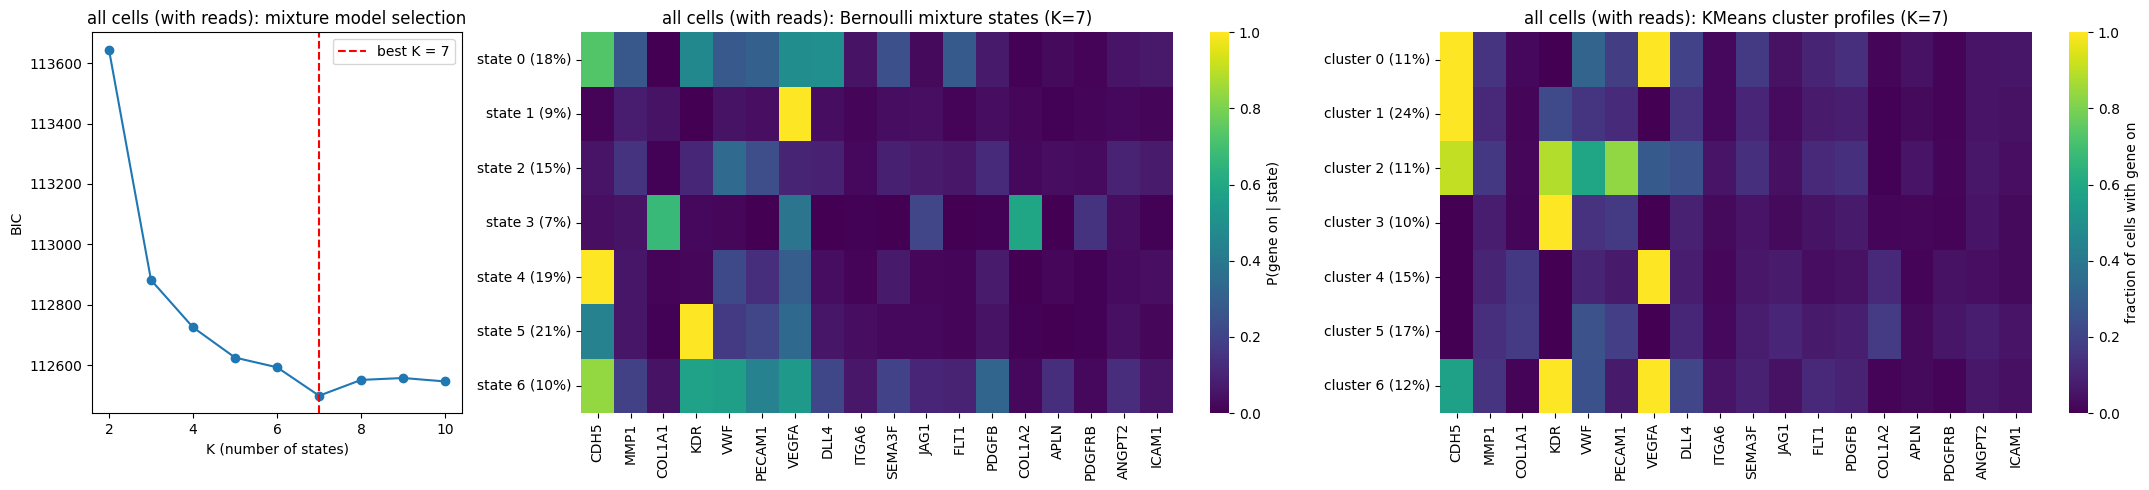

Agreement for all cells (with reads) at K=7 (1 = identical, ~0 = chance):
        kmeans vs bernoulli   : AMI = 0.506



In [18]:
# ============================================================================
# RUN SECTION 2 - Bernoulli + KMeans on three population scopes:
#   (a) the WHOLE population (all-0-read cells excluded),
#   (b) endothelial (all cells), and (c) fibroblast (all cells).
# ============================================================================
MAX_CLUSTERS = 10
CELL_TYPES = ["endothelial", "fibroblast"]  # lineages carried into section 3

# Section 3 reads these per-cell columns; the per-lineage 'all cells' runs below fill
# them (offset so the two lineages keep distinct ids). Reset them first.
for column in ["bmm", "kmeans", "consensus"]:
    df[column] = -1
df["consensus_confidence"] = np.nan

# (a) WHOLE population - every cell with >=1 read, both lineages + unknown together.
# It overlaps the per-lineage runs, so its labels are NOT stored back to df.
res_pop = cluster_and_report(df, "all cells (with reads)", max_clusters=MAX_CLUSTERS)


POPULATION: endothelial (all cells)  (7,388 cells with reads)
Bernoulli BIC picked K = 7; forcing K on KMeans.

7 clusters identified for endothelial (all cells) cells (KMeans, 7,388 cells):
  cluster 0 (1,736 cells, 23%): likely states include 38% 1 (CDH5); 15% 1_7 (CDH5, VEGFA); 7% 1_6 (CDH5, PECAM1)
  cluster 3 (1,161 cells, 16%): likely states include 40% 4 (KDR); 15% 4_7 (KDR, VEGFA); 6% 4_5 (KDR, VWF)
  cluster 2 (1,121 cells, 15%): likely states include 16% 1_5 (CDH5, VWF); 10% 1_5_7 (CDH5, VWF, VEGFA); 7% 1_4_5 (CDH5, KDR, VWF)
  cluster 5 (1,070 cells, 14%): likely states include 24% 1_4 (CDH5, KDR); 18% 1_4_7 (CDH5, KDR, VEGFA); 9% 1_4_6 (CDH5, KDR, PECAM1)
  cluster 1 (986 cells, 13%): likely states include 5% 1_8 (CDH5, DLL4); 4% 1_7_8 (CDH5, VEGFA, DLL4); 3% 1_4_8 (CDH5, KDR, DLL4)
  cluster 4 (703 cells, 10%): likely states include 32% 5 (VWF); 8% 13 (PDGFB); 7% 5_7 (VWF, VEGFA)
  cluster 6 (611 cells, 8%): likely states include 19% 6 (PECAM1); 15% 4_6 (KDR, PECAM1); 6% 4

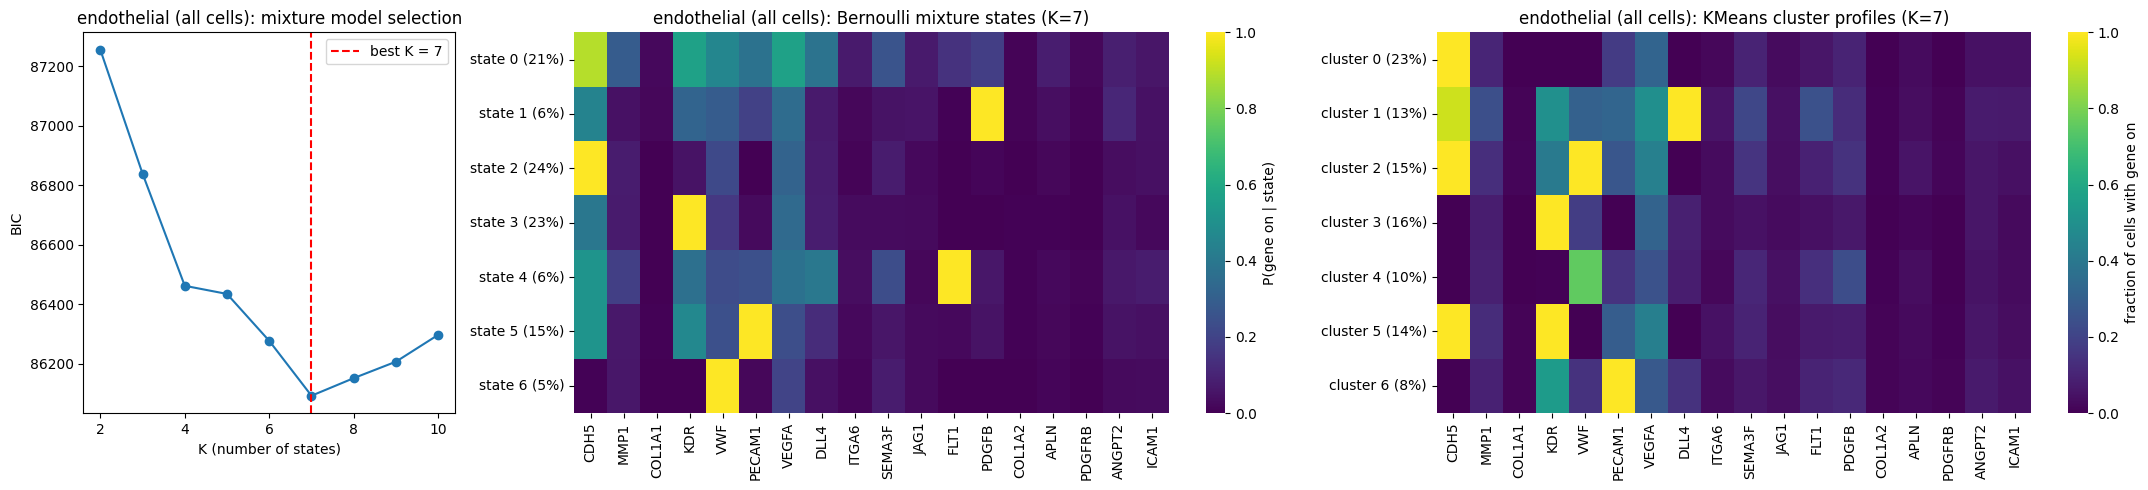

Agreement for endothelial (all cells) at K=7 (1 = identical, ~0 = chance):
        kmeans vs bernoulli   : AMI = 0.405

Consensus (co-association of the 2 methods, K=7):
     bernoulli vs consensus  : AMI = 0.893
        kmeans vs consensus  : AMI = 0.483
  mean per-cell confidence: 0.677; cells with >=0.8 confidence: 35.5%

7 clusters identified for endothelial (all cells) cells (Consensus, 7,388 cells):
  cluster 5 (1,786 cells, 24%): likely states include 37% 1 (CDH5); 14% 1_7 (CDH5, VEGFA); 10% 1_5 (CDH5, VWF)
  cluster 1 (1,643 cells, 22%): likely states include 28% 4 (KDR); 16% 1_4 (CDH5, KDR); 12% 1_4_7 (CDH5, KDR, VEGFA)
  cluster 7 (1,455 cells, 20%): likely states include 3% 1_8 (CDH5, DLL4); 3% 1_7_8 (CDH5, VEGFA, DLL4); 2% 1_4_8 (CDH5, KDR, DLL4)
  cluster 4 (1,105 cells, 15%): likely states include 11% 1_6 (CDH5, PECAM1); 10% 6 (PECAM1); 8% 4_6 (KDR, PECAM1)
  cluster 6 (540 cells, 7%): likely states include 6% 12 (FLT1); 4% 1_12 (CDH5, FLT1); 3% 1_4_12 (CDH5, KDR, FLT1)
 

In [19]:
# (b) ENDOTHELIAL - confident-only vs all endothelial cells (with reads).
# 'all cells' is stored back to df for the downstream neighbourhood analysis.
res_endo_all = cluster_and_report(
    df[(df.cell_type == "endothelial")], "endothelial (all cells)",
    max_clusters=MAX_CLUSTERS, store_to_df=True)

POPULATION: fibroblast (all cells)  (732 cells with reads)
Bernoulli BIC picked K = 3; forcing K on KMeans.

3 clusters identified for fibroblast (all cells) cells (KMeans, 732 cells):
  cluster 0 (281 cells, 38%): likely states include 37% 3_14 (COL1A1, COL1A2); 28% 3 (COL1A1); 9% 3_11_14 (COL1A1, JAG1, COL1A2)
  cluster 2 (245 cells, 33%): likely states include 31% 3_7 (COL1A1, VEGFA); 22% 3_7_14 (COL1A1, VEGFA, COL1A2); 6% 3_7_11 (COL1A1, VEGFA, JAG1)
  cluster 1 (206 cells, 28%): likely states include 37% 14 (COL1A2); 23% 7_14 (VEGFA, COL1A2); 13% 16 (PDGFRB)



c:\Users\taylorhearn\AppData\Local\miniforge3\envs\sequencing\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


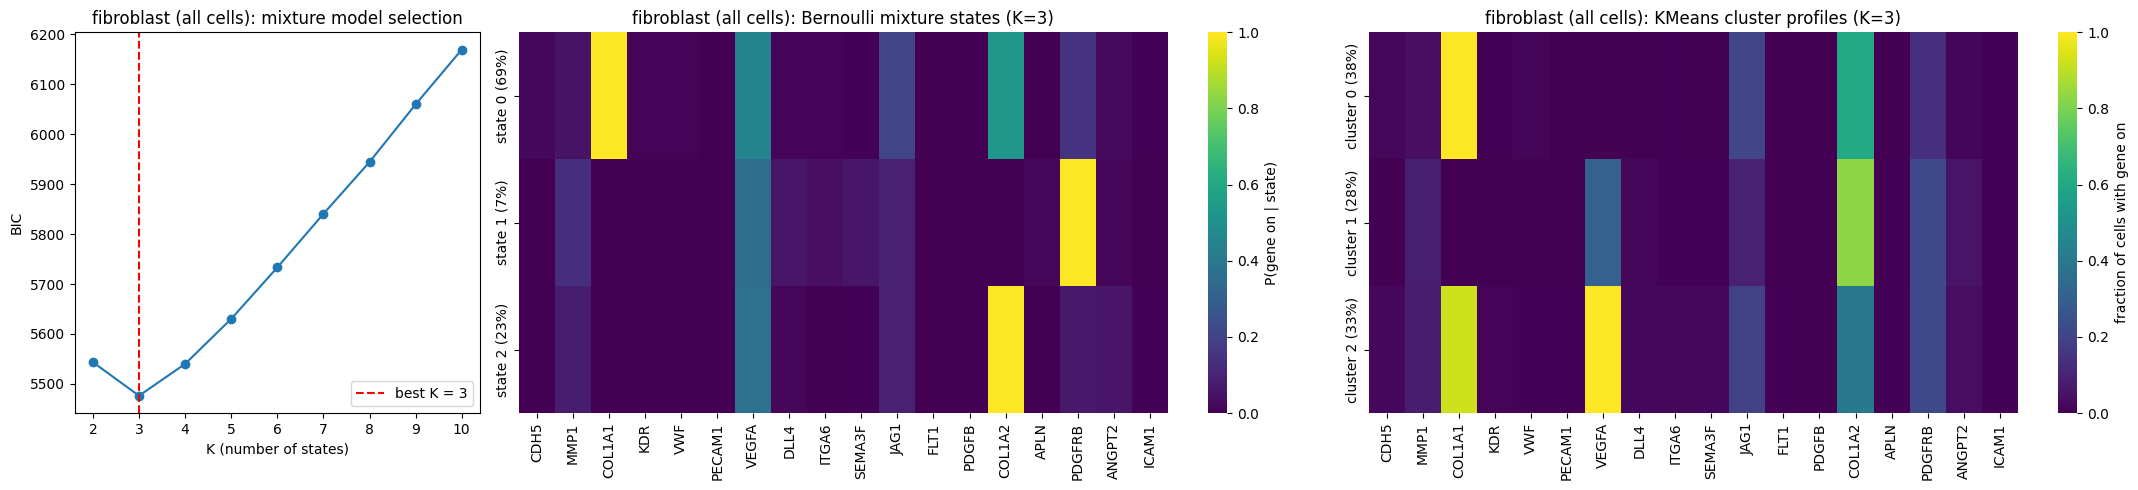

Agreement for fibroblast (all cells) at K=3 (1 = identical, ~0 = chance):
        kmeans vs bernoulli   : AMI = 0.603

Consensus (co-association of the 2 methods, K=3):
     bernoulli vs consensus  : AMI = 0.603
        kmeans vs consensus  : AMI = 1.000
  mean per-cell confidence: 0.936; cells with >=0.8 confidence: 92.6%

3 clusters identified for fibroblast (all cells) cells (Consensus, 732 cells):
  cluster 2 (281 cells, 38%): likely states include 37% 3_14 (COL1A1, COL1A2); 28% 3 (COL1A1); 9% 3_11_14 (COL1A1, JAG1, COL1A2)
  cluster 3 (245 cells, 33%): likely states include 31% 3_7 (COL1A1, VEGFA); 22% 3_7_14 (COL1A1, VEGFA, COL1A2); 6% 3_7_11 (COL1A1, VEGFA, JAG1)
  cluster 1 (206 cells, 28%): likely states include 37% 14 (COL1A2); 23% 7_14 (VEGFA, COL1A2); 13% 16 (PDGFRB)



In [20]:
# (c) FIBROBLAST - confident-only vs all fibroblast cells (with reads).
# 'all cells' is stored back to df for the downstream neighbourhood analysis.
res_fibro_all = cluster_and_report(
    df[(df.cell_type == "fibroblast")], "fibroblast (all cells)",
    max_clusters=MAX_CLUSTERS, store_to_df=True)


In [49]:
# Collect every run's cluster summary into one tidy table.
all_runs = [res_pop, res_endo_all, res_fibro_all]
cluster_overview = pd.concat([r["summaries"] for r in all_runs if r is not None],
                             ignore_index=True)
cluster_overview.to_csv(output_dir / "section2_cluster_overview.csv", index=False)
print("Saved -> section2_cluster_overview.csv")


Saved -> section2_cluster_overview.csv


### What the results mean - the short version

**1. We used two different clustering methods, on purpose.** Grouping cells by their 18-gene on/off profile can depend on *how* you cluster, so we ran two methods that make **different assumptions** and only trust what they agree on:
- **KMeans** (distance-based): a group is a **centroid** (its per-gene ON-fraction) and each cell joins the nearest one. It weights every gene equally and gives each cell one hard label.
- **Bernoulli mixture** (probabilistic): a group is a hidden **state** with a per-gene ON-*probability*; each cell is a noisy draw from one state (soft assignment). It down-weights inconsistent genes, assumes genes switch on independently within a state, and treats a 0 as a true "off". The Bernoulli mixture picks the number of groups K (by BIC) and that same K is forced on KMeans, so any disagreement is real, not a granularity mismatch.

**2. The two methods largely recover the same groups.** We measure agreement with a single score, the **Adjusted Mutual Information (AMI)** - how much one method's labels tell you about the other's, corrected for chance (`1` = identical, `0` = random). We use AMI rather than the Rand index because our groups are very uneven in size, which AMI handles better.

| Condition | K | AMI (KMeans ↔ Bernoulli) |
|---|---|---|
| all cells (with reads) | 7 | 0.51 |
| endothelial | 7 | 0.41 |
| fibroblast | 3 | 0.60 |

Agreement is well above chance everywhere. It is **strong and clean for fibroblasts** (a few discrete states) and **moderate for endothelial cells**, which behave more like a *continuum* of activation than a set of sharp types - the exact number of endothelial groups is therefore softer.

**3. We report only the "consensus cells" - the ones we're confident about.** Fusing the two partitions by **co-association** (cells kept together only when *both* methods group them together) gives a single consensus labelling plus a **per-cell confidence** = how consistently the two methods co-group that cell with its group-mates (`1.0` = always, `~0.5` = the methods disagree). For the figure below we keep only **confident cells (confidence ≥ 0.8)** and show each consensus group's per-gene ON-fraction - i.e. the clusters we actually trust.

This is where the fibroblast-vs-endothelial contrast shows up plainly: **~93% of fibroblast cells are confident** (clean, discrete states - `COL1A1`/`COL1A2` collagen-high, a `COL1A1`+`VEGFA` programme, and a `COL1A2`/`PDGFRB` programme), whereas **only ~35% of endothelial cells are** (a confident `CDH5`+ / `KDR`-`VEGFA` angiogenic core sitting in a broader continuum). The table under the figure lists the AMI, the % of confident cells, and the number of confident groups for each condition.



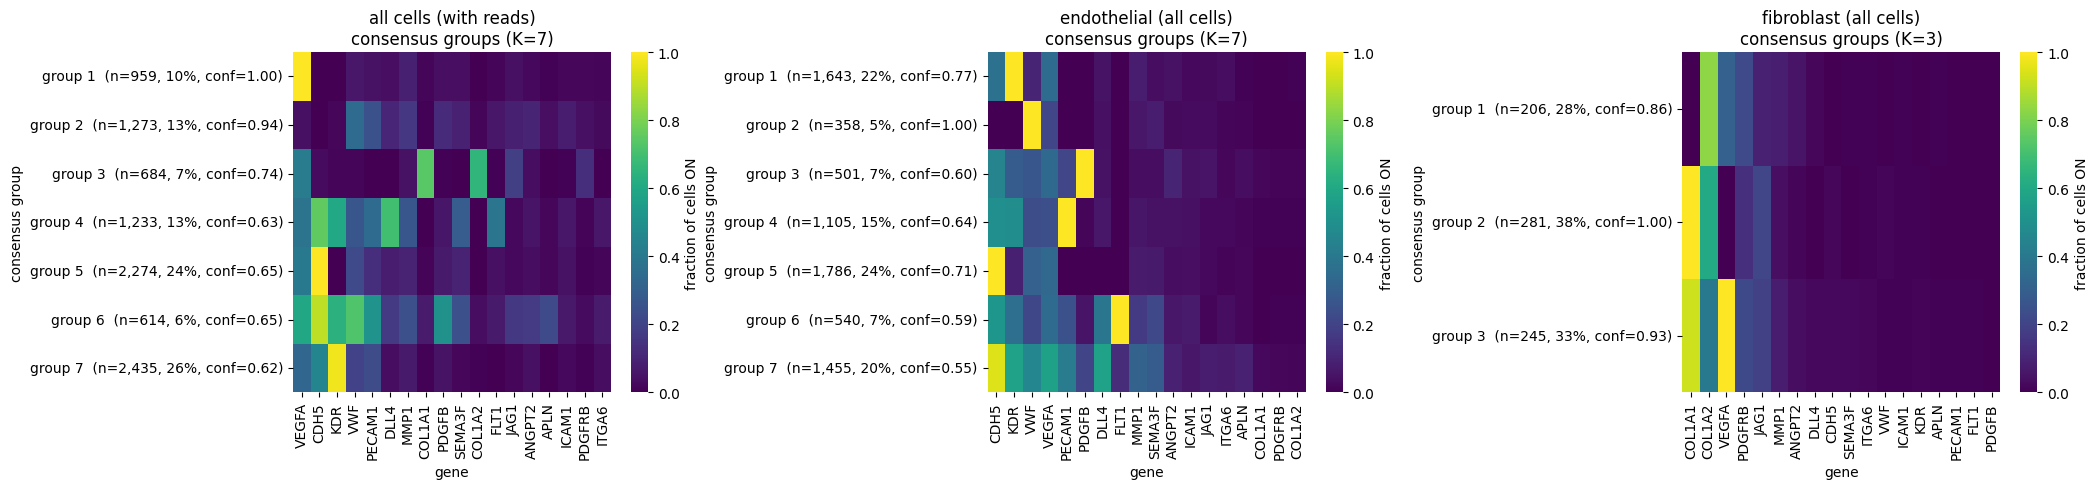

In [ ]:
# ============================================================================
# PRESENTATION VIEW - the clusters we TRUST. For each condition we keep only the
# "consensus cells" (per-cell confidence >= 0.8: cells BOTH methods co-group), then show
# each consensus group's per-gene ON-fraction. The compact table reports the single
# agreement score (AMI), the % of cells that are confident, and how many groups survive.
# The whole-population consensus exceeds the 8000-cell cap inside consensus_labels, so we
# recompute it here (cap lifted) for plotting.
# ============================================================================
CONF_THRESHOLD = 0.8

runs = [res_pop, res_endo_all, res_fibro_all]
fig, axes = plt.subplots(1, len(runs), figsize=(7 * len(runs), 5), squeeze=False)
summary_rows = []

for ax, res in zip(axes[0], runs):
    if res is None:
        ax.axis("off")
        continue
    cells = res["cells"]
    gene_matrix = cells[GENES].astype(int).to_numpy()
    cons, conf = res["consensus"], res["consensus_confidence"]
    if cons is None:  # >8000 cells -> recompute the consensus just for this figure
        cons, conf = consensus_labels(res["method_labels"], n_clusters=res["K"],
                                      max_cells=len(cells) + 1)
    cons = np.asarray(cons); conf = np.asarray(conf, dtype=float)

    # "consensus cells" = the confident core both methods agree on
    confident = conf >= CONF_THRESHOLD
    pct_confident = 100 * confident.mean()

    rows, index = [], []
    for g in np.unique(cons[confident]):
        mask = confident & (cons == g)
        rows.append(gene_matrix[mask].mean(axis=0))
        index.append(f"group {g}  (n={int(mask.sum()):,})")
    profiles = pd.DataFrame(rows, columns=GENES, index=index)
    # order genes by overall ON-fraction so the structure reads left-to-right
    profiles = profiles[profiles.mean(axis=0).sort_values(ascending=False).index]

    sns.heatmap(profiles, cmap="viridis", vmin=0, vmax=1, ax=ax,
                cbar_kws={"label": "fraction of cells ON"})
    ax.set_title(f"{res['label']}\nconfident consensus groups "
                 f"(AMI={res['ami']:.2f}, {pct_confident:.0f}% confident)")
    ax.set_xlabel("gene")
    ax.set_ylabel("consensus group")

    summary_rows.append({
        "condition": res["label"],
        "K": res["K"],
        "AMI": round(res["ami"], 3),
        "n_cells": len(cells),
        "pct_confident_>=0.8": round(pct_confident, 1),
        "n_confident_groups": len(profiles),
    })

plt.tight_layout()
fig.savefig(output_dir / "section2_consensus_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

# One-line-per-condition story: how much the methods agree and how clean the groups are.
consensus_summary = pd.DataFrame(summary_rows)
consensus_summary.to_csv(output_dir / "section2_consensus_summary.csv", index=False)
print("Saved -> section2_consensus_summary.csv")
display(consensus_summary)


## 3. Neighbourhood analysis

We now describe each cell by its **local micro-environment** rather than its own genes:
the cell-type composition of its spatial neighbours, how many neighbours express each
gene, the **Shannon entropy** of the neighbourhood (diversity), and the **local
density**. Clustering these neighbourhood vectors defines recurring tissue **niches**,
which we relate back to gene state - and we then test whether whole gene states
(e.g. `1_4_7` vs `1_4_8`) co-locate in space.


In [100]:
# NEIGHBOURHOOD ANALYSIS. For every cell we describe its local micro-environment from
# its k nearest spatial neighbours *within the same image* (in microns):
#   - cell-type composition   (% endothelial / fibroblast / unknown)
#   - neighbourhood expression (% of neighbours expressing each gene)
#   - Shannon entropy          (diversity of neighbour cell types)
#   - local density            (number of neighbours within a fixed radius)


K_SPATIAL = 15         # neighbours used for composition / expression
RADIUS_UM = 30.0       # radius (microns) used for the local-density count

ct_dummies = (pd.get_dummies(df["cell_type"])
              .reindex(columns=CT_ORDER, fill_value=0).to_numpy().astype(float))

feat_ct   = np.zeros((len(df), len(CT_ORDER)))
feat_gene = np.zeros((len(df), len(GENES)))
entropy   = np.zeros(len(df))
density   = np.zeros(len(df))

for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    k = min(K_SPATIAL + 1, len(sub))
    _, nb = tree.query(coords, k=k)
    nb = np.atleast_2d(nb)
    neigh = nb[:, 1:] if nb.shape[1] > 1 else nb   # drop self column
    gneigh = ii[neigh]                             # local -> global indices
    feat_ct[ii]   = ct_dummies[gneigh].mean(axis=1)
    feat_gene[ii] = X[gneigh].mean(axis=1)
    comp = feat_ct[ii]
    entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
    density[ii] = np.array([len(x) - 1 for x in tree.query_ball_point(coords, RADIUS_UM)])

nbhd = pd.DataFrame(feat_ct, columns=[f"nb_%{c}" for c in CT_ORDER], index=df.index)
nbhd = pd.concat(
    [nbhd, pd.DataFrame(feat_gene, columns=[f"nb_{g}" for g in GENES], index=df.index)],
    axis=1)
nbhd["nb_entropy"] = entropy
nbhd["nb_density"] = density
df[nbhd.columns] = nbhd


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_218360\3404930806.py:32: RuntimeWarning: divide by zero encountered in log
  entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_218360\3404930806.py:32: RuntimeWarning: invalid value encountered in multiply
  entropy[ii] = -np.sum(np.where(comp > 0, comp * np.log(comp), 0.0), axis=1)


In [ ]:
# Cluster the NEIGHBOURHOODS (not the cells) to define recurring micro-environments
# ("niches"), then ask how a cell's gene state relates to the niche it sits in. This
# links gene state <-> tissue context.

nb_feature_cols = ([f"nb_%{c}" for c in CT_ORDER] +
                   [f"nb_{g}" for g in GENES] + ["nb_entropy", "nb_density"])
Zf = StandardScaler().fit_transform(df[nb_feature_cols].values)

n_niches = 6
df["niche"] = KMeans(n_clusters=n_niches, n_init=10, random_state=0).fit_predict(Zf)

# Mean feature profile of each niche.
niche_profile = df.groupby("niche")[nb_feature_cols].mean()
plt.figure(figsize=(12, 5))
sns.heatmap(niche_profile.T, cmap="vlag", center=0, robust=True,
            cbar_kws={"label": "mean (raw units)"})
plt.title(f"Neighbourhood niches (KMeans, k={n_niches}) - feature profiles")
plt.xlabel("niche"); plt.tight_layout(); plt.show()

# Link gene-state cluster (KMeans) to niche.
plt.figure(figsize=(9, 6))
sns.heatmap(pd.crosstab(df["kmeans"], df["niche"], normalize="index"),
            annot=True, fmt=".2f", cmap="Blues")
plt.title("P(niche | gene-state KMeans cluster)")
plt.xlabel("niche"); plt.ylabel("KMeans cluster")
plt.tight_layout(); plt.show()

In [ ]:
# Do whole gene STATES co-locate in space? Rather than looking at single genes, we
# test complete states: for each of the most common states we measure the fraction of
# a cell's spatial neighbours carrying each other state, then compare to that state's
# global abundance. log2(observed / expected) > 0 means the two states sit together in
# tissue more than chance - so we can ask e.g. whether 1_4_7 and 1_4_8 co-locate.
top_states = df["state_code"].value_counts().head(15).index.tolist()
state_of = df["state_code"].values
global_freq = df["state_code"].value_counts(normalize=True)

obs = pd.DataFrame(0.0, index=top_states, columns=top_states)
cnt = pd.Series(0, index=top_states, dtype=float)
for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    k = min(K_SPATIAL + 1, len(sub))
    _, nb = tree.query(coords, k=k)
    nb = np.atleast_2d(nb)
    neigh = nb[:, 1:] if nb.shape[1] > 1 else nb
    gneigh = ii[neigh]
    for row, centre_state in zip(gneigh, state_of[ii]):
        if centre_state not in top_states:
            continue
        cnt[centre_state] += 1
        nbr_states = state_of[row]
        for t in top_states:
            obs.loc[centre_state, t] += np.mean(nbr_states == t)

obs = obs.div(cnt.replace(0, np.nan), axis=0)
enrich = np.log2(obs.div(global_freq[top_states], axis=1) + 1e-6)

plt.figure(figsize=(10, 8))
sns.heatmap(enrich, cmap="coolwarm", center=0,
            cbar_kws={"label": "log2 observed / expected"})
plt.title("Spatial co-location of gene states (neighbour enrichment)")
plt.xlabel("neighbour state"); plt.ylabel("centre-cell state")
plt.tight_layout(); plt.show()


## 4. Graph-based approaches

Two complementary graphs:

* **Spatial graph** - nodes = cells, edges = cells within a chosen radius in the same
  image. Used for spatial communities (Leiden), a cell-type **neighbour-enrichment**
  permutation test, and local density.
* **State graph** - nodes = unique gene states, edges connect states differing by a
  single gene (`1` -> `1_4` -> `1_4_7`). Node size = abundance; colour = mean local
  density or % endothelial, revealing how states relate and where they sit in tissue.


In [ ]:
# GRAPH VIEW 1 - spatial graph. Nodes = cells, edges = cell pairs within RADIUS_UM in
# the SAME image. We (a) detect spatial communities with Leiden, (b) run a cell-type
# neighbour-enrichment permutation test (are endothelial cells next to fibroblasts more
# or less than chance?), and (c) visualise the largest image.

# Build one combined spatial graph (node ids = df row index); edges stay within images.
edges_sp = []
for _, sub in df.groupby(IMAGE_KEY):
    ii = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    for a, b in tree.query_pairs(RADIUS_UM):
        edges_sp.append((int(ii[a]), int(ii[b])))

g_sp = ig.Graph(n=len(df), edges=edges_sp)
sp_part = leidenalg.find_partition(g_sp, leidenalg.RBConfigurationVertexPartition,
                                   resolution_parameter=1.0, seed=0)
df["spatial_community"] = np.array(sp_part.membership)
print(f"Spatial graph: {g_sp.ecount():,} edges, "
      f"{df['spatial_community'].nunique()} communities")

# Cell-type neighbour-enrichment permutation test (squidpy-style z-scores).
ct_cat = df["cell_type"].astype("category")
codes = ct_cat.cat.codes.to_numpy()
cats = list(ct_cat.cat.categories)
E = np.array(g_sp.get_edgelist())

def _edge_counts(lbl):
    m = np.zeros((len(cats), len(cats)))
    for u, v in zip(lbl[E[:, 0]], lbl[E[:, 1]]):
        m[u, v] += 1
        m[v, u] += 1
    return m

obs_m = _edge_counts(codes)
rng = np.random.default_rng(0)
perm = np.stack([_edge_counts(rng.permutation(codes)) for _ in range(200)])
z = (obs_m - perm.mean(0)) / (perm.std(0) + 1e-9)
z_df = pd.DataFrame(z, index=cats, columns=cats)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(z_df, cmap="coolwarm", center=0, annot=True, fmt=".1f", square=True,
            ax=axes[0], cbar_kws={"label": "enrichment z-score"})
axes[0].set_title("Cell-type neighbour enrichment (200 permutations)")

# Visualise the largest image in space, coloured by cell type.
big = df[IMAGE_KEY].value_counts().idxmax()
sub = df[df[IMAGE_KEY] == big]
for ct in CT_ORDER:
    s = sub[sub.cell_type == ct]
    axes[1].scatter(s.x_um, s.y_um, s=10, color=CT_COLORS[ct], label=ct, alpha=0.7)
axes[1].set_aspect("equal")
axes[1].legend(markerscale=2)
axes[1].set_title(f"Image '{big}' - cells in space")
axes[1].set_xlabel("x (um)"); axes[1].set_ylabel("y (um)")
plt.tight_layout(); plt.show()


In [ ]:
# GRAPH VIEW 2 - state graph. Nodes = unique recurrent gene states; edges connect
# states differing by exactly ONE gene (Hamming distance 1), so the graph maps how
# states are built up gene-by-gene (e.g. 1 -> 1_4 -> 1_4_7). Node size = abundance;
# we colour once by mean local density and once by % endothelial cells in the state.

state_stats = (
    df.groupby("state_code")
    .agg(n_cells=("state_code", "size"),
         density=("nb_density", "mean"),
         pct_epi=("cell_type", lambda s: (s == "endothelial").mean()))
    .reset_index()
)
# One binary vector per state (states are unique on binary_state).
state_vec = {
    sc: np.array([int(c) for c in df.loc[df.state_code == sc, "binary_state"].iloc[0]])
    for sc in state_stats["state_code"]
}

G = nx.Graph()
for r in state_stats.itertuples():
    G.add_node(r.state_code, n=r.n_cells, density=r.density, pct_epi=r.pct_epi)
for s1, s2 in combinations(state_stats["state_code"].tolist(), 2):
    if int(np.abs(state_vec[s1] - state_vec[s2]).sum()) == 1:
        G.add_edge(s1, s2)

pos = nx.spring_layout(G, seed=0, k=0.5)
sizes = np.array([G.nodes[n]["n"] for n in G], dtype=float)
sizes = 20 + 400 * sizes / sizes.max()

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, key, cmap in [(axes[0], "density", "viridis"),
                      (axes[1], "pct_epi", "coolwarm")]:
    vals = [G.nodes[n][key] for n in G]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3)
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes,
                                   node_color=vals, cmap=cmap)
    plt.colorbar(nodes, ax=ax, label=key)
    ax.set_title(f"State graph - node size = abundance, colour = {key}")
    ax.axis("off")
plt.tight_layout(); plt.show()

print(f"State graph: {G.number_of_nodes()} states, "
      f"{G.number_of_edges()} single-gene transitions")


In [ ]:
# Recurrent-state heatmap: rows = states, columns = genes 1-18, values = on/off.
# A side annotation shows n_cells and % of all cells, making families (e.g. 1_4,
# 1_4_7, 1_4_11, 1_4_12) easy to spot.
top_n = 20
top_states = state_summary.head(top_n).copy()

state_onoff = pd.DataFrame(
    [[int(ch) for ch in bs] for bs in top_states["binary_state"]],
    columns=[f"{i + 1}:{g}" for i, g in enumerate(true_gene_columns)],
    index=top_states["state_code"],
)

fig, (ax_hm, ax_bar) = plt.subplots(
    1, 2, figsize=(12, 0.45 * top_n + 2),
    gridspec_kw={"width_ratios": [4, 1.4], "wspace": 0.05}, sharey=True,
    constrained_layout=True,
)

ax_hm.imshow(state_onoff.values, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax_hm.set_xticks(range(len(state_onoff.columns)))
ax_hm.set_xticklabels(state_onoff.columns, rotation=90, fontsize=8)
ax_hm.set_yticks(range(len(state_onoff.index)))
ax_hm.set_yticklabels(state_onoff.index, fontsize=8)
ax_hm.set_xlabel("Gene (index : name)")
ax_hm.set_ylabel("State code")
ax_hm.set_title(f"Top {top_n} recurrent states (black = on)")

y = np.arange(len(top_states))
ax_bar.barh(y, top_states["n_cells"], color="steelblue")
ax_bar.set_xlabel("n cells")
ax_bar.set_title("Frequency")
for yi, (n, pct) in enumerate(zip(top_states["n_cells"], top_states["pct_all_cells"])):
    ax_bar.text(n, yi, f" {n} ({pct:.1f}%)", va="center", fontsize=7)
ax_bar.set_ylim(ax_hm.get_ylim())  # align bars with heatmap rows
plt.show()



In [ ]:
# Cluster the recurrent states using Hamming distance on the 18-gene binary
# vectors with average-linkage hierarchical clustering.
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

hamming_threshold = 0.20  # states within this fractional bit-difference are grouped

state_vectors = np.array(
    [[int(ch) for ch in bs] for bs in state_summary["binary_state"]], dtype=np.uint8
)

dist_condensed = pdist(state_vectors, metric="hamming")
Z = linkage(dist_condensed, method="average")
state_summary["cluster_id"] = fcluster(Z, t=hamming_threshold, criterion="distance")

dist_matrix = squareform(dist_condensed)
np.fill_diagonal(dist_matrix, np.inf)
state_summary["nearest_neighbor_hamming"] = dist_matrix.min(axis=1)

# Per-cluster summary.
cluster_summary = (
    state_summary.groupby("cluster_id")
    .agg(
        n_states=("state_code", "size"),
        n_cells=("n_cells", "sum"),
        example_states=("state_code", lambda s: ", ".join(s.head(5))),
    )
    .reset_index()
    .sort_values("n_cells", ascending=False)
    .reset_index(drop=True)
)
cluster_summary["pct_all_cells"] = 100 * cluster_summary["n_cells"] / n_total

# Dendrogram of recurrent states.
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, labels=state_summary["state_code"].values, color_threshold=hamming_threshold, ax=ax)
ax.axhline(hamming_threshold, color="red", ls="--", lw=1, label=f"cut = {hamming_threshold}")
ax.set_xlabel("State code")
ax.set_ylabel("Hamming distance")
ax.set_title("Hierarchical clustering of recurrent states (Hamming, average linkage)")
ax.legend()
plt.xticks(fontsize=6)
plt.tight_layout()
plt.show()

print(f"{len(state_summary)} recurrent states -> {state_summary['cluster_id'].nunique()} clusters")
display(cluster_summary.head(20))

# Save outputs.
state_summary.to_csv(output_dir / "recurrent_states_summary.csv", index=False)
cluster_summary.to_csv(output_dir / "recurrent_state_clusters.csv", index=False)
print("Saved -> recurrent_states_summary.csv, recurrent_state_clusters.csv")
